In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, accuracy_score, roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_pca = pd.read_csv('/content/pca_selected.csv')

In [7]:
df_pca.head()

,PC_1,PC_2,PC_3,PC_4,PC_6,PC_7,PC_8,PC_9,PC_10,PC_12,num
0,1.162722,-0.929622,3.212341,2.248647,0.164221,0.966571,-0.596128,-1.484567,-0.453161,0.497023,0
1,3.217830,-1.451021,-0.481532,-0.849814,-0.631340,0.403677,1.058591,0.419353,1.475782,-0.942472,1
2,3.143604,0.636569,-0.364301,-0.607485,-1.003931,0.681505,0.185650,0.057853,0.470704,0.895176,1
3,-0.464908,1.409706,0.395323,2.797258,-0.160742,-0.644582,-2.159004,0.877933,0.243848,0.170085,0
4,-2.268663,-0.388683,-0.068956,1.170135,-0.141872,0.729038,0.033008,1.067675,0.553453,-0.281023,0


In [4]:
df_rfe = pd.read_csv('/content/features_selected_rfe.csv')

In [8]:
X_pca = df_pca.drop(columns=['num'])
y = df_pca['num']
X_rfe = df_rfe.drop(columns=['num'])
y_rfe = df_rfe['num']

In [9]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(X_rfe, y_rfe, test_size=0.2, random_state=42)

**Logistic Regression**

Logistic Regression with PCA features:
Training Accuracy: 0.8471074380165289
Test Accuracy: 0.9016393442622951
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90        29
           1       0.91      0.91      0.91        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Confusion Matrix:
 [[26  3]
 [ 3 29]]
AUC: 0.9288793103448276


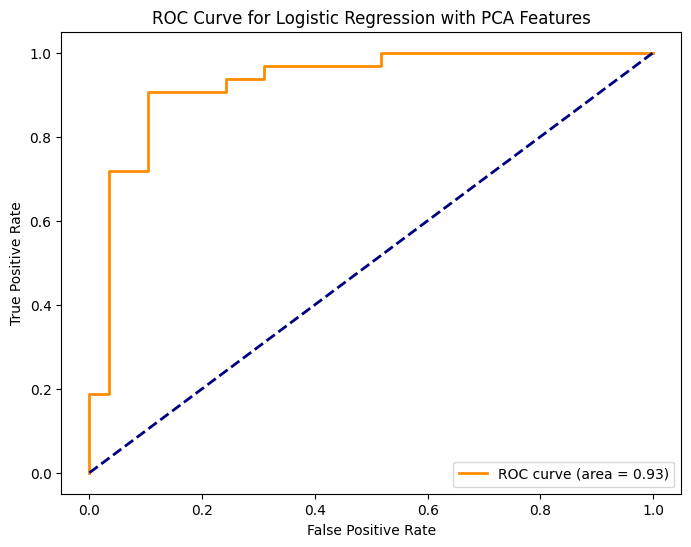


Logistic Regression with RFE features:
Training Accuracy: 0.8429752066115702
Test Accuracy: 0.8852459016393442
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Confusion Matrix:
 [[26  3]
 [ 4 28]]
AUC: 0.925646551724138


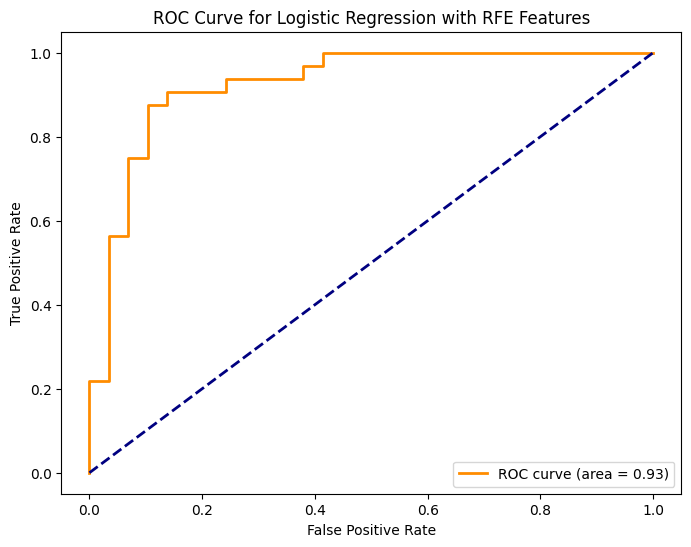

In [11]:
# Logistic Regression with PCA features
lr_pca = LogisticRegression(random_state=42)
lr_pca.fit(X_train_pca, y_train_pca)
y_pred_pca_lr = lr_pca.predict(X_test_pca)
y_prob_pca_lr = lr_pca.predict_proba(X_test_pca)[:, 1]
y_train_pred_pca_lr = lr_pca.predict(X_train_pca) # Predictions on training data

print("Logistic Regression with PCA features:")
print("Training Accuracy:", accuracy_score(y_train_pca, y_train_pred_pca_lr)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_pca, y_pred_pca_lr))
print("Classification Report:\n", classification_report(y_test_pca, y_pred_pca_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test_pca, y_pred_pca_lr))

# Calculate ROC Curve and AUC
fpr_pca_lr, tpr_pca_lr, thresholds_pca_lr = roc_curve(y_test_pca, y_prob_pca_lr)
auc_pca_lr = auc(fpr_pca_lr, tpr_pca_lr)
print("AUC:", auc_pca_lr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_pca_lr, tpr_pca_lr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_pca_lr)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with PCA Features')
plt.legend(loc="lower right")
plt.show()


# Logistic Regression with RFE features
lr_rfe = LogisticRegression(random_state=42)
lr_rfe.fit(X_train_rfe, y_train_rfe)
y_pred_rfe_lr = lr_rfe.predict(X_test_rfe)
y_prob_rfe_lr = lr_rfe.predict_proba(X_test_rfe)[:, 1]
y_train_pred_rfe_lr = lr_rfe.predict(X_train_rfe) # Predictions on training data

print("\nLogistic Regression with RFE features:")
print("Training Accuracy:", accuracy_score(y_train_rfe, y_train_pred_rfe_lr)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_rfe, y_pred_rfe_lr))
print("Classification Report:\n", classification_report(y_test_rfe, y_pred_rfe_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test_rfe, y_pred_rfe_lr))

# Calculate ROC Curve and AUC
fpr_rfe_lr, tpr_rfe_lr, thresholds_rfe_lr = roc_curve(y_test_rfe, y_prob_rfe_lr)
auc_rfe_lr = auc(fpr_rfe_lr, tpr_rfe_lr)
print("AUC:", auc_rfe_lr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rfe_lr, tpr_rfe_lr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_rfe_lr)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with RFE Features')
plt.legend(loc="lower right")
plt.show()

**Decision Tree**

Decision Tree with PCA features:
Training Accuracy: 1.0
Test Accuracy: 0.8032786885245902
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.83      0.78      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61

Confusion Matrix:
 [[24  5]
 [ 7 25]]
AUC: 0.8044181034482758


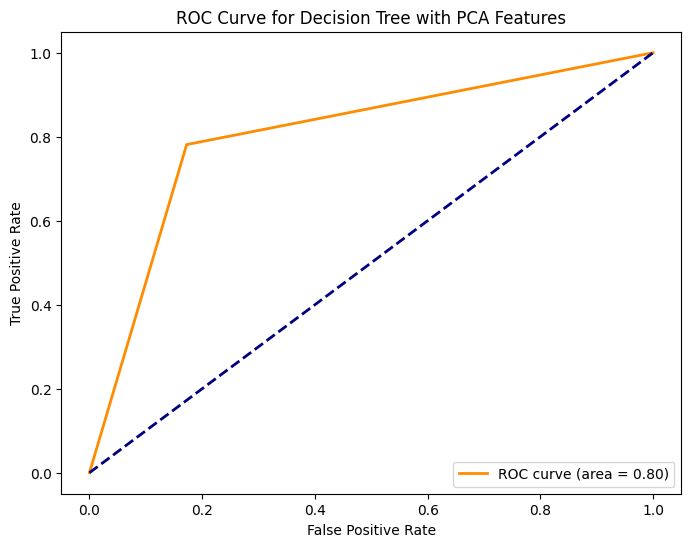


Decision Tree with RFE features:
Training Accuracy: 1.0
Test Accuracy: 0.7377049180327869
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.73        29
           1       0.77      0.72      0.74        32

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61

Confusion Matrix:
 [[22  7]
 [ 9 23]]
AUC: 0.7386853448275862


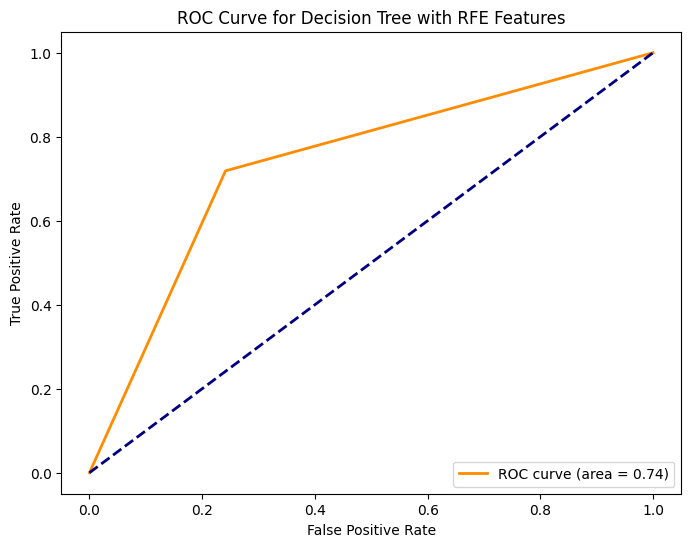

In [12]:
# Decision Tree with PCA features
dt_pca = DecisionTreeClassifier(random_state=42)
dt_pca.fit(X_train_pca, y_train_pca)
y_pred_pca_dt = dt_pca.predict(X_test_pca)
y_prob_pca_dt = dt_pca.predict_proba(X_test_pca)[:, 1]
y_train_pred_pca_dt = dt_pca.predict(X_train_pca) # Predictions on training data


print("Decision Tree with PCA features:")
print("Training Accuracy:", accuracy_score(y_train_pca, y_train_pred_pca_dt)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_pca, y_pred_pca_dt))
print("Classification Report:\n", classification_report(y_test_pca, y_pred_pca_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test_pca, y_pred_pca_dt))

# Calculate ROC Curve and AUC
fpr_pca_dt, tpr_pca_dt, thresholds_pca_dt = roc_curve(y_test_pca, y_prob_pca_dt)
auc_pca_dt = auc(fpr_pca_dt, tpr_pca_dt)
print("AUC:", auc_pca_dt)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_pca_dt, tpr_pca_dt, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_pca_dt)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree with PCA Features')
plt.legend(loc="lower right")
plt.show()


# Decision Tree with RFE features
dt_rfe = DecisionTreeClassifier(random_state=42)
dt_rfe.fit(X_train_rfe, y_train_rfe)
y_pred_rfe_dt = dt_rfe.predict(X_test_rfe)
y_prob_rfe_dt = dt_rfe.predict_proba(X_test_rfe)[:, 1]
y_train_pred_rfe_dt = dt_rfe.predict(X_train_rfe) # Predictions on training data


print("\nDecision Tree with RFE features:")
print("Training Accuracy:", accuracy_score(y_train_rfe, y_train_pred_rfe_dt)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_rfe, y_pred_rfe_dt))
print("Classification Report:\n", classification_report(y_test_rfe, y_pred_rfe_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test_rfe, y_pred_rfe_dt))

# Calculate ROC Curve and AUC
fpr_rfe_dt, tpr_rfe_dt, thresholds_rfe_dt = roc_curve(y_test_rfe, y_prob_rfe_dt)
auc_rfe_dt = auc(fpr_rfe_dt, tpr_rfe_dt)
print("AUC:", auc_rfe_dt)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rfe_dt, tpr_rfe_dt, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_rfe_dt)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree with RFE Features')
plt.legend(loc="lower right")
plt.show()

**Random Forest**

Random Forest with PCA features:
Training Accuracy: 1.0
Test Accuracy: 0.8688524590163934
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Confusion Matrix:
 [[27  2]
 [ 6 26]]
AUC: 0.9272629310344828


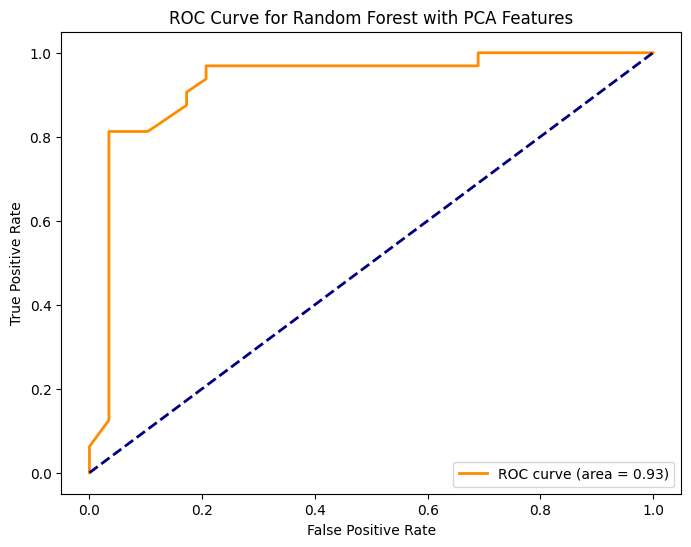


Random Forest with RFE features:
Training Accuracy: 1.0
Test Accuracy: 0.8688524590163934
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion Matrix:
 [[26  3]
 [ 5 27]]
AUC: 0.9331896551724138


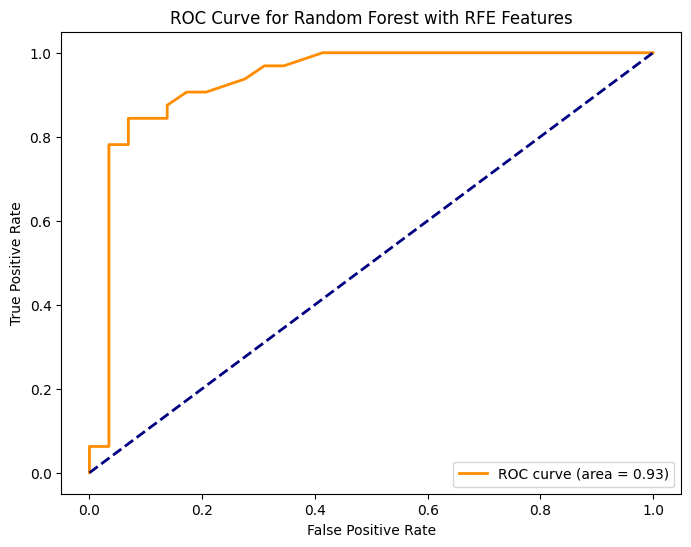

In [13]:
# Random Forest with PCA features
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train_pca)
y_pred_pca_rf = rf_pca.predict(X_test_pca)
y_prob_pca_rf = rf_pca.predict_proba(X_test_pca)[:, 1]
y_train_pred_pca_rf = rf_pca.predict(X_train_pca) # Predictions on training data

print("Random Forest with PCA features:")
print("Training Accuracy:", accuracy_score(y_train_pca, y_train_pred_pca_rf)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_pca, y_pred_pca_rf))
print("Classification Report:\n", classification_report(y_test_pca, y_pred_pca_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test_pca, y_pred_pca_rf))

# Calculate ROC Curve and AUC
fpr_pca_rf, tpr_pca_rf, thresholds_pca_rf = roc_curve(y_test_pca, y_prob_pca_rf)
auc_pca_rf = auc(fpr_pca_rf, tpr_pca_rf)
print("AUC:", auc_pca_rf)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_pca_rf, tpr_pca_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_pca_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest with PCA Features')
plt.legend(loc="lower right")
plt.show()


# Random Forest with RFE features
rf_rfe = RandomForestClassifier(random_state=42)
rf_rfe.fit(X_train_rfe, y_train_rfe)
y_pred_rfe_rf = rf_rfe.predict(X_test_rfe)
y_prob_rfe_rf = rf_rfe.predict_proba(X_test_rfe)[:, 1]
y_train_pred_rfe_rf = rf_rfe.predict(X_train_rfe) # Predictions on training data

print("\nRandom Forest with RFE features:")
print("Training Accuracy:", accuracy_score(y_train_rfe, y_train_pred_rfe_rf)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_rfe, y_pred_rfe_rf))
print("Classification Report:\n", classification_report(y_test_rfe, y_pred_rfe_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test_rfe, y_pred_rfe_rf))

# Calculate ROC Curve and AUC
fpr_rfe_rf, tpr_rfe_rf, thresholds_rfe_rf = roc_curve(y_test_rfe, y_prob_rfe_rf)
auc_rfe_rf = auc(fpr_rfe_rf, tpr_rfe_rf)
print("AUC:", auc_rfe_rf)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rfe_rf, tpr_rfe_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_rfe_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest with RFE Features')
plt.legend(loc="lower right")
plt.show()

**Support Vector Machine (SVM)**

Support Vector Machine with PCA features:
Training Accuracy: 0.8925619834710744
Test Accuracy: 0.9344262295081968
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61

Confusion Matrix:
 [[28  1]
 [ 3 29]]
AUC: 0.9396551724137931


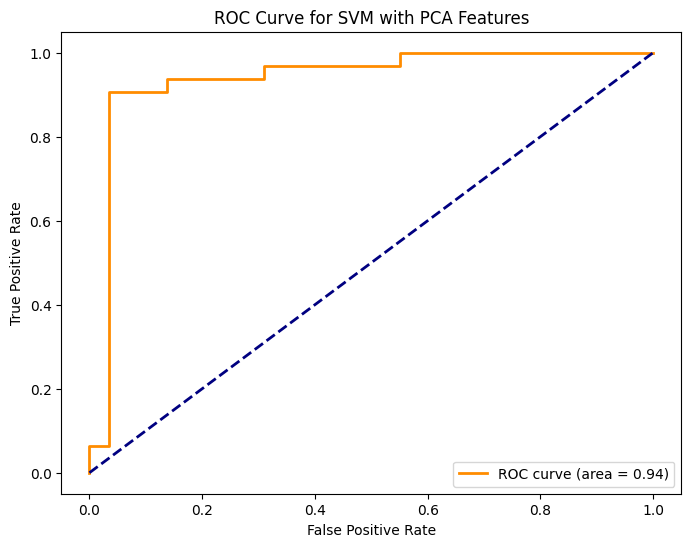


Support Vector Machine with RFE features:
Training Accuracy: 0.8925619834710744
Test Accuracy: 0.8852459016393442
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89        29
           1       0.96      0.81      0.88        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.88        61

Confusion Matrix:
 [[28  1]
 [ 6 26]]
AUC: 0.9418103448275861


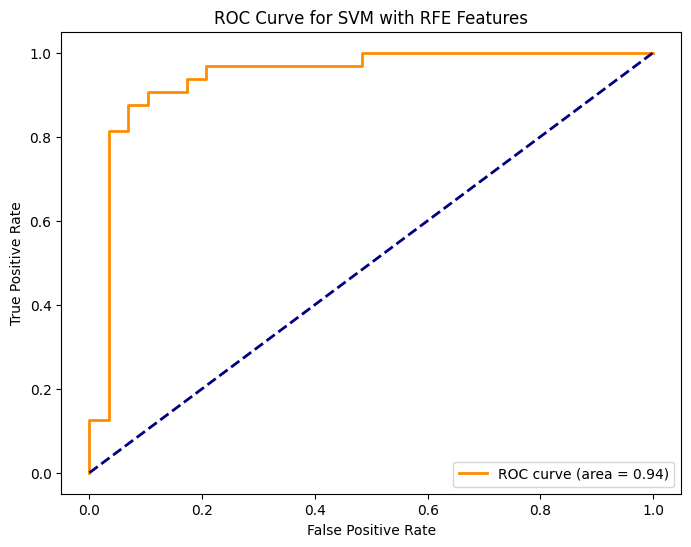

In [14]:
# SVM with PCA features
svm_pca = SVC(probability=True, random_state=42) # probability=True is needed for roc_curve
svm_pca.fit(X_train_pca, y_train_pca)
y_pred_pca_svm = svm_pca.predict(X_test_pca)
y_prob_pca_svm = svm_pca.predict_proba(X_test_pca)[:, 1]
y_train_pred_pca_svm = svm_pca.predict(X_train_pca) # Predictions on training data


print("Support Vector Machine with PCA features:")
print("Training Accuracy:", accuracy_score(y_train_pca, y_train_pred_pca_svm)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_pca, y_pred_pca_svm))
print("Classification Report:\n", classification_report(y_test_pca, y_pred_pca_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test_pca, y_pred_pca_svm))

# Calculate ROC Curve and AUC
fpr_pca_svm, tpr_pca_svm, thresholds_pca_svm = roc_curve(y_test_pca, y_prob_pca_svm)
auc_pca_svm = auc(fpr_pca_svm, tpr_pca_svm)
print("AUC:", auc_pca_svm)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_pca_svm, tpr_pca_svm, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_pca_svm)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM with PCA Features')
plt.legend(loc="lower right")
plt.show()


# SVM with RFE features
svm_rfe = SVC(probability=True, random_state=42) # probability=True is needed for roc_curve
svm_rfe.fit(X_train_rfe, y_train_rfe)
y_pred_rfe_svm = svm_rfe.predict(X_test_rfe)
y_prob_rfe_svm = svm_rfe.predict_proba(X_test_rfe)[:, 1]
y_train_pred_rfe_svm = svm_rfe.predict(X_train_rfe) # Predictions on training data


print("\nSupport Vector Machine with RFE features:")
print("Training Accuracy:", accuracy_score(y_train_rfe, y_train_pred_rfe_svm)) # Training Accuracy
print("Test Accuracy:", accuracy_score(y_test_rfe, y_pred_rfe_svm))
print("Classification Report:\n", classification_report(y_test_rfe, y_pred_rfe_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test_rfe, y_pred_rfe_svm))

# Calculate ROC Curve and AUC
fpr_rfe_svm, tpr_rfe_svm, thresholds_rfe_svm = roc_curve(y_test_rfe, y_prob_rfe_svm)
auc_rfe_svm = auc(fpr_rfe_svm, tpr_rfe_svm)
print("AUC:", auc_rfe_svm)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rfe_svm, tpr_rfe_svm, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_rfe_svm)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM with RFE Features')
plt.legend(loc="lower right")
plt.show()

**Performance Comparison**

In [16]:
# Create a dictionary to store the results
results = {
    'Model': ['Logistic Regression (PCA)', 'Logistic Regression (RFE)',
              'Decision Tree (PCA)', 'Decision Tree (RFE)',
              'Random Forest (PCA)', 'Random Forest (RFE)',
              'SVM (PCA)', 'SVM (RFE)'],
    'Training Accuracy': [accuracy_score(y_train_pca, y_train_pred_pca_lr), accuracy_score(y_train_rfe, y_train_pred_rfe_lr),
                          accuracy_score(y_train_pca, y_train_pred_pca_dt), accuracy_score(y_train_rfe, y_train_pred_rfe_dt),
                          accuracy_score(y_train_pca, y_train_pred_pca_rf), accuracy_score(y_train_rfe, y_train_pred_rfe_rf),
                          accuracy_score(y_train_pca, y_train_pred_pca_svm), accuracy_score(y_train_rfe, y_train_pred_rfe_svm)],
    'Test Accuracy': [accuracy_score(y_test_pca, y_pred_pca_lr), accuracy_score(y_test_rfe, y_pred_rfe_lr),
                      accuracy_score(y_test_pca, y_pred_pca_dt), accuracy_score(y_test_rfe, y_pred_rfe_dt),
                      accuracy_score(y_test_pca, y_pred_pca_rf), accuracy_score(y_test_rfe, y_pred_rfe_rf),
                      accuracy_score(y_test_pca, y_pred_pca_svm), accuracy_score(y_test_rfe, y_pred_rfe_svm)],
    'AUC': [auc_pca_lr, auc_rfe_lr,
            auc_pca_dt, auc_rfe_dt,
            auc_pca_rf, auc_rfe_rf,
            auc_pca_svm, auc_rfe_svm]
}

# Create a pandas DataFrame from the results
results_df = pd.DataFrame(results)

# Display the performance comparison table
print("Performance Comparison:")
display(results_df)

Performance Comparison:


,Model,Training Accuracy,Test Accuracy,AUC
0,Logistic Regression (PCA),0.847107,0.901639,0.928879
1,Logistic Regression (RFE),0.842975,0.885246,0.925647
2,Decision Tree (PCA),1.000000,0.803279,0.804418
3,Decision Tree (RFE),1.000000,0.737705,0.738685
4,Random Forest (PCA),1.000000,0.868852,0.927263
5,Random Forest (RFE),1.000000,0.868852,0.933190
6,SVM (PCA),0.892562,0.934426,0.939655
7,SVM (RFE),0.892562,0.885246,0.941810


In [17]:
# Save the trained models with RFE features
joblib.dump(lr_rfe, 'logistic_regression_rfe.pkl')
joblib.dump(dt_rfe, 'decision_tree_rfe.pkl')
joblib.dump(rf_rfe, 'random_forest_rfe.pkl')
joblib.dump(svm_rfe, 'svm_rfe.pkl')

# Download the saved models
from google.colab import files

files.download('logistic_regression_rfe.pkl')
files.download('decision_tree_rfe.pkl')
files.download('random_forest_rfe.pkl')
files.download('svm_rfe.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>